# Atividade 2 — Condições de máquinas com K-Means

Agrupar registros de sensores para descobrir padrões de operação e possíveis condições anormais.

**Arquivo de dados:** `maquinas_kmeans.csv`

> Regra central: as colunas de referência servem somente para avaliar o resultado no final. Elas não podem entrar em `X`.

## 1. Importe as bibliotecas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEMENTE = 42

## 2. Carregue e inspecione os dados

Analise tipos, dimensões, estatísticas e valores ausentes.

In [3]:
# TODO: carregue maquinas_kmeans.csv
df = pd.read_csv("maquinas_kmeans.csv")
display(df.head())
print("Dimensoes:", df.shape)
display(df.describe(include="all"))
print("Ausentes por coluna:\n", df.isna().sum())

,registro_id,temperatura_c,vibracao_mm_s,pressao_bar,consumo_kw,ruido_db,condicao_referencia
0,REG001,59.9,1.84,5.76,27.3,66.9,normal
1,REG002,61.6,1.43,6.05,22.1,65.8,normal
2,REG003,58.8,2.19,5.55,21.7,63.2,normal
3,REG004,63.0,1.77,5.81,23.4,69.9,normal
4,REG005,53.2,1.87,6.15,22.5,67.3,normal


Dimensoes: (90, 7)


,registro_id,temperatura_c,vibracao_mm_s,pressao_bar,consumo_kw,ruido_db,condicao_referencia
count,90,90.000000,90.000000,90.000000,90.000000,90.000000,90
unique,90,NaN,NaN,NaN,NaN,NaN,3
top,REG001,NaN,NaN,NaN,NaN,NaN,normal
freq,1,NaN,NaN,NaN,NaN,NaN,30
mean,NaN,71.093333,4.402667,6.158444,30.677778,77.470000,NaN
std,NaN,10.767583,2.152030,1.030802,6.015201,8.827695,NaN
min,NaN,53.200000,1.430000,4.540000,18.900000,61.300000,NaN
25%,NaN,61.750000,2.280000,5.285000,25.500000,69.750000,NaN
50%,NaN,68.450000,3.975000,5.930000,29.650000,78.100000,NaN
75%,NaN,82.800000,6.710000,7.217500,35.900000,84.775000,NaN


Ausentes por coluna:
 registro_id            0
temperatura_c          0
vibracao_mm_s          0
pressao_bar            0
consumo_kw             0
ruido_db               0
condicao_referencia    0
dtype: int64


## 3. Prepare X e padronize

Não use `registro_id` nem `condicao_referencia`. Padronize todas as leituras dos sensores.

In [4]:
# TODO: defina as cinco colunas de sensores
colunas = ["temperatura_c", "vibracao_mm_s", "pressao_bar", "consumo_kw", "ruido_db"]
X = df[colunas]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

## 4. Escolha K

Teste de 2 a 6 clusters com inércia e silhueta.

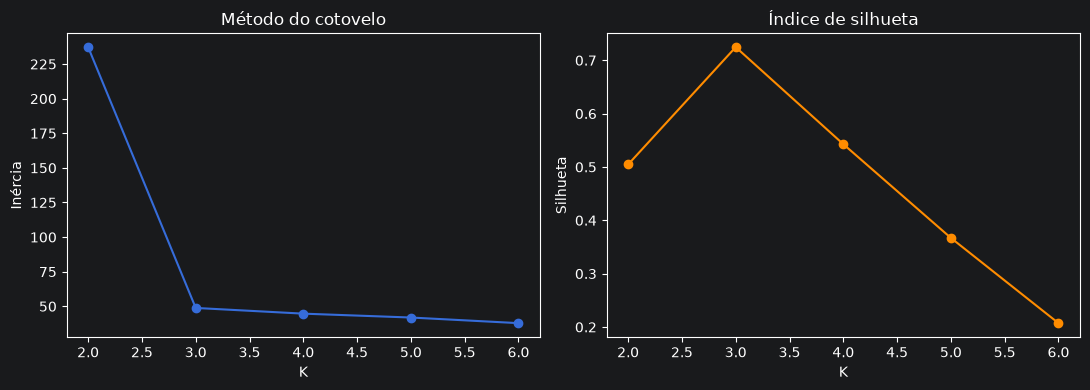

In [5]:
# TODO: crie o laco para valores_k = range(2, 7)

valores_k = range(2, 7)
inercias, silhuetas = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    grupos = modelo.fit_predict(X_padronizado)
    # TODO: armazene inertia_ e silhouette_score
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, grupos))

# TODO: produza os dois graficos
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="K", ylabel="Inércia")
eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Índice de silhueta", xlabel="K", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 5. Modelo final e centroides

Treine K=3. Mostre as médias por cluster e também converta os centroides para as unidades originais com `scaler.inverse_transform`.

,temperatura_c,vibracao_mm_s,pressao_bar,consumo_kw,ruido_db
cluster,,,,,
0,84.62,3.96,7.45,37.62,77.77
1,68.41,7.11,5.08,30.20,87.43
2,60.25,2.13,5.94,24.22,67.21


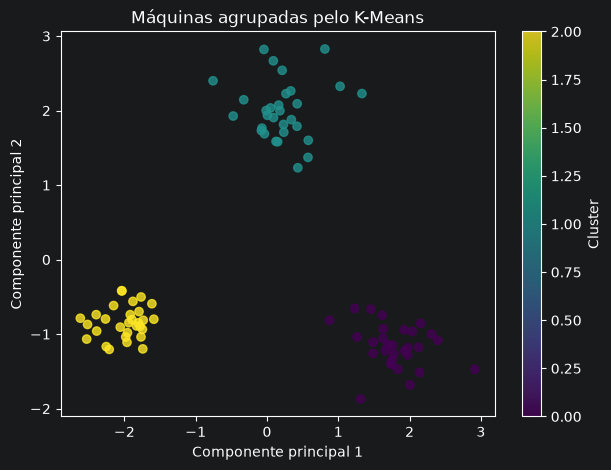

In [6]:
# TODO: treine o KMeans
kmeans = KMeans(n_clusters=3, random_state=SEMENTE, n_init=10)
clusters = kmeans.fit_predict(X_padronizado)
df["cluster"] = clusters
resumo = df.groupby("cluster")[colunas].mean().round(2)
display(resumo)

# TODO: reduza para duas dimensoes com PCA e desenhe o grafico
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_padronizado)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Máquinas agrupadas pelo K-Means")
plt.colorbar(label="Cluster")
plt.show()

## 6. Avalie usando o rótulo de referência

Somente agora compare os clusters com `condicao_referencia`. A numeração 0, 1 e 2 é arbitrária.

In [7]:
# TODO: crie uma tabela cruzada entre df["condicao_referencia"] e clusters
tabela = pd.crosstab(df["condicao_referencia"], df["cluster"], rownames=["referencia"], colnames=["cluster"])

# TODO: calcule o ARI
ari = adjusted_rand_score(df["condicao_referencia"], clusters)
display(tabela)
print(f"ARI: {ari:.4f}")

cluster,0,1,2
referencia,,,
desgaste,0,30,0
normal,0,0,30
sobrecarga,30,0,0


ARI: 1.0000


## 7. Interprete

Responda em uma nova célula Markdown:

1. Qual valor de K parece melhor pelo cotovelo e pela silhueta?
2. O que caracteriza cada cluster? Use as médias das variáveis.
3. O ARI indica boa concordância com a referência?
4. Por que os números dos clusters não precisam coincidir com os nomes reais?
5. O que poderia mudar se os dados não fossem padronizados?

Variáveis analisadas: temperatura, vibração, pressão, consumo, ruído.